# 02 · Load & visualise **two separate** FIBO ontologies

Same load→transform pipeline as notebook 01 (no LPG export), but here we load
**two** ontologies and visualise them both — individually and combined:

| # | Ontology | File | Role |
|---|----------|------|------|
| 1 | FIBO **Foundational** | `FND/Parties/Parties.rdf` | foundational parties/roles |
| 2 | FIBO **Persons & Accounts** | `FBC/ProductsAndServices/ClientsAndAccounts.rdf` | accounts and their holders (persons/organizations = clients) |

Each is loaded independently (`follow_imports=False`) into its own IR, then merged
with `compose_named`, which tags every node with its **source** ontology — and
marks any node shared by both as **`shared`** (the cross-references that bridge the
two otherwise-separate modules).

In [1]:
%matplotlib inline
import nb_helpers as h        # local module; wires in ../ontology_to_lpg.py
import pandas as pd

FIBO = h.find_fibo_root()
print("FIBO clone:", FIBO)

FIBO clone: C:\Users\marci\OneDrive\DEV\EDU\AIML\Graph ML\Ontology Engineering\Ontology Repository\FIBO\fibo


In [2]:
found_file = FIBO / "FND" / "Parties" / "Parties.rdf"
acct_file  = FIBO / "FBC" / "ProductsAndServices" / "ClientsAndAccounts.rdf"

ir_found = h.load_ontology_ir(found_file, follow_imports=False)
ir_acct  = h.load_ontology_ir(acct_file,  follow_imports=False)

print(f"Foundational (Parties):        {ir_found.number_of_nodes():3d} nodes, "
      f"{ir_found.number_of_edges():3d} edges")
print(f"Persons & Accounts (Clients…): {ir_acct.number_of_nodes():3d} nodes, "
      f"{ir_acct.number_of_edges():3d} edges")

Foundational (Parties):         17 nodes,  10 edges
Persons & Accounts (Clients…): 106 nodes,  97 edges


## Per-ontology label counts

In [3]:
a = h.summarize_ir(ir_found)["labels"].rename(columns={"count": "Foundational"})
b = h.summarize_ir(ir_acct)["labels"].rename(columns={"count": "Persons&Accounts"})
a.merge(b, on="node_label", how="outer").fillna(0)

,node_label,Foundational,Persons&Accounts
0,DatatypeProperty,0.0,2
1,OWLClass,6.0,51
2,ObjectProperty,3.0,15
3,Ontology,1.0,1
4,Resource,7.0,37


## Ontology 1 — FIBO Foundational (Parties)

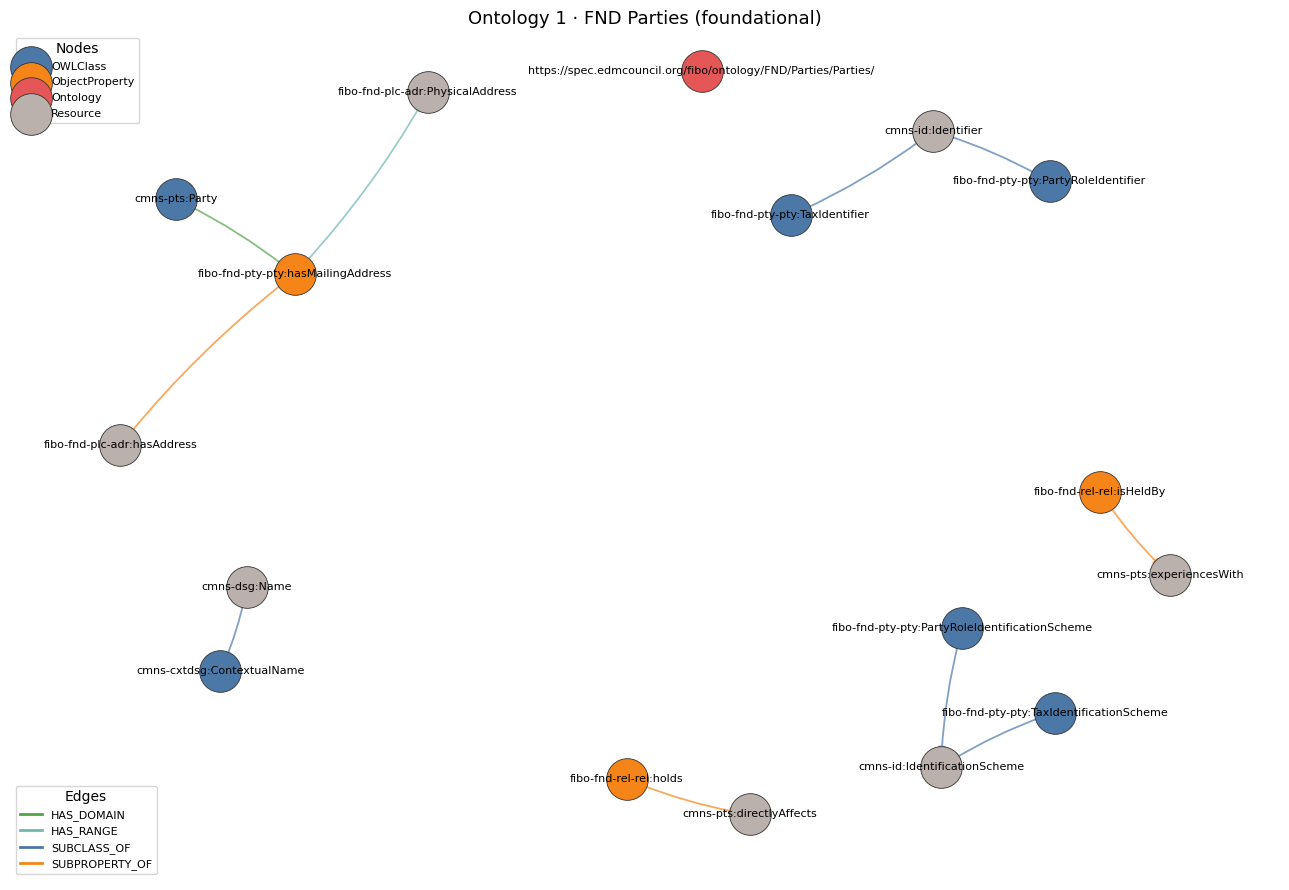

In [4]:
h.draw_meta_graph(ir_found, "Ontology 1 · FND Parties (foundational)",
                  color_by="label", figsize=(13, 9))

## Ontology 2 — FIBO Persons & Accounts (Clients & Accounts)

This module is large (51 classes), so we visualise its **class taxonomy** — the
`OWLClass` nodes and their `SUBCLASS_OF` edges — for readability.

Class taxonomy: 51 classes, 19 subclass edges


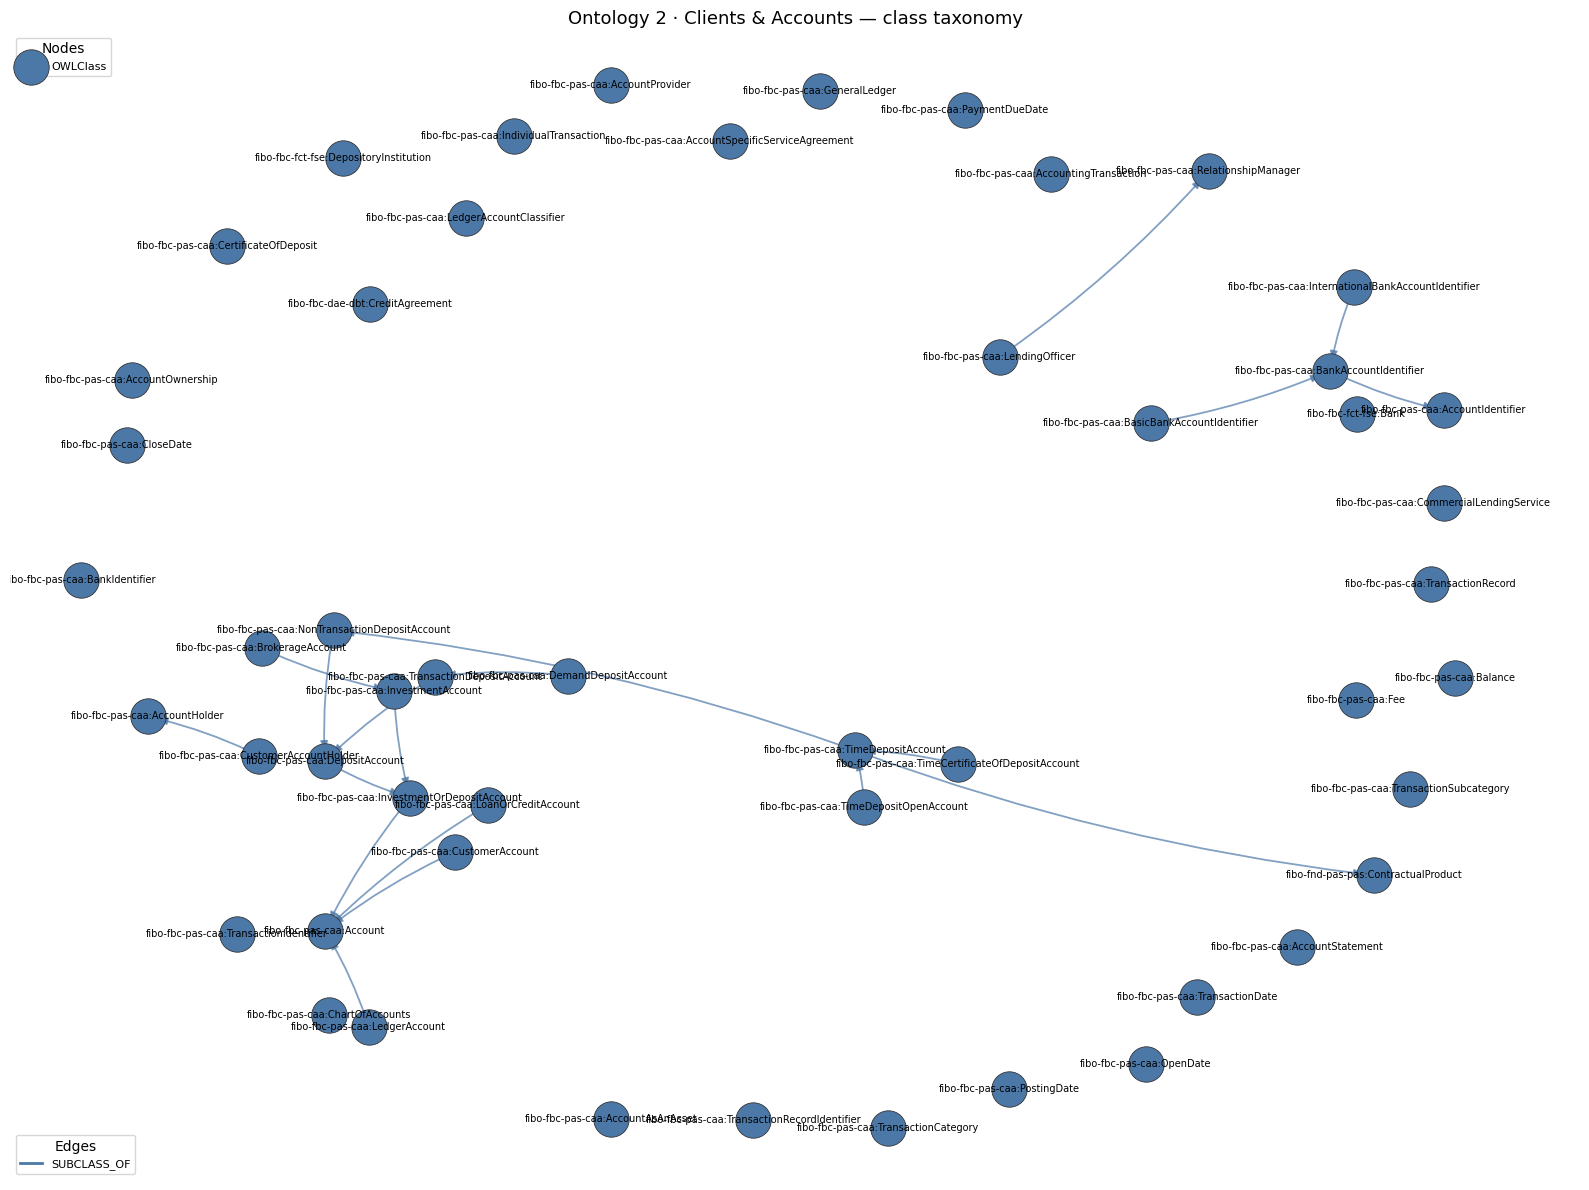

In [5]:
acct_taxonomy = h.filter_ir(ir_acct, keep_labels={"OWLClass"},
                            keep_edge_types={"SUBCLASS_OF"})
print(f"Class taxonomy: {acct_taxonomy.number_of_nodes()} classes, "
      f"{acct_taxonomy.number_of_edges()} subclass edges")
h.draw_meta_graph(acct_taxonomy, "Ontology 2 · Clients & Accounts — class taxonomy",
                  color_by="label", figsize=(16, 12), node_size=650, font_size=7)

## Combined view — coloured by source ontology

Both ontologies in one graph. Blue = Foundational, orange = Persons & Accounts,
red = **shared** nodes (referenced by both). We drop each side's private
`Resource` import-stubs but keep the shared ones, so the bridge between the two
modules stays visible.

nodes by source: {'FND: Parties': 15, 'shared': 2, 'FBC: ClientsAndAccounts': 104}


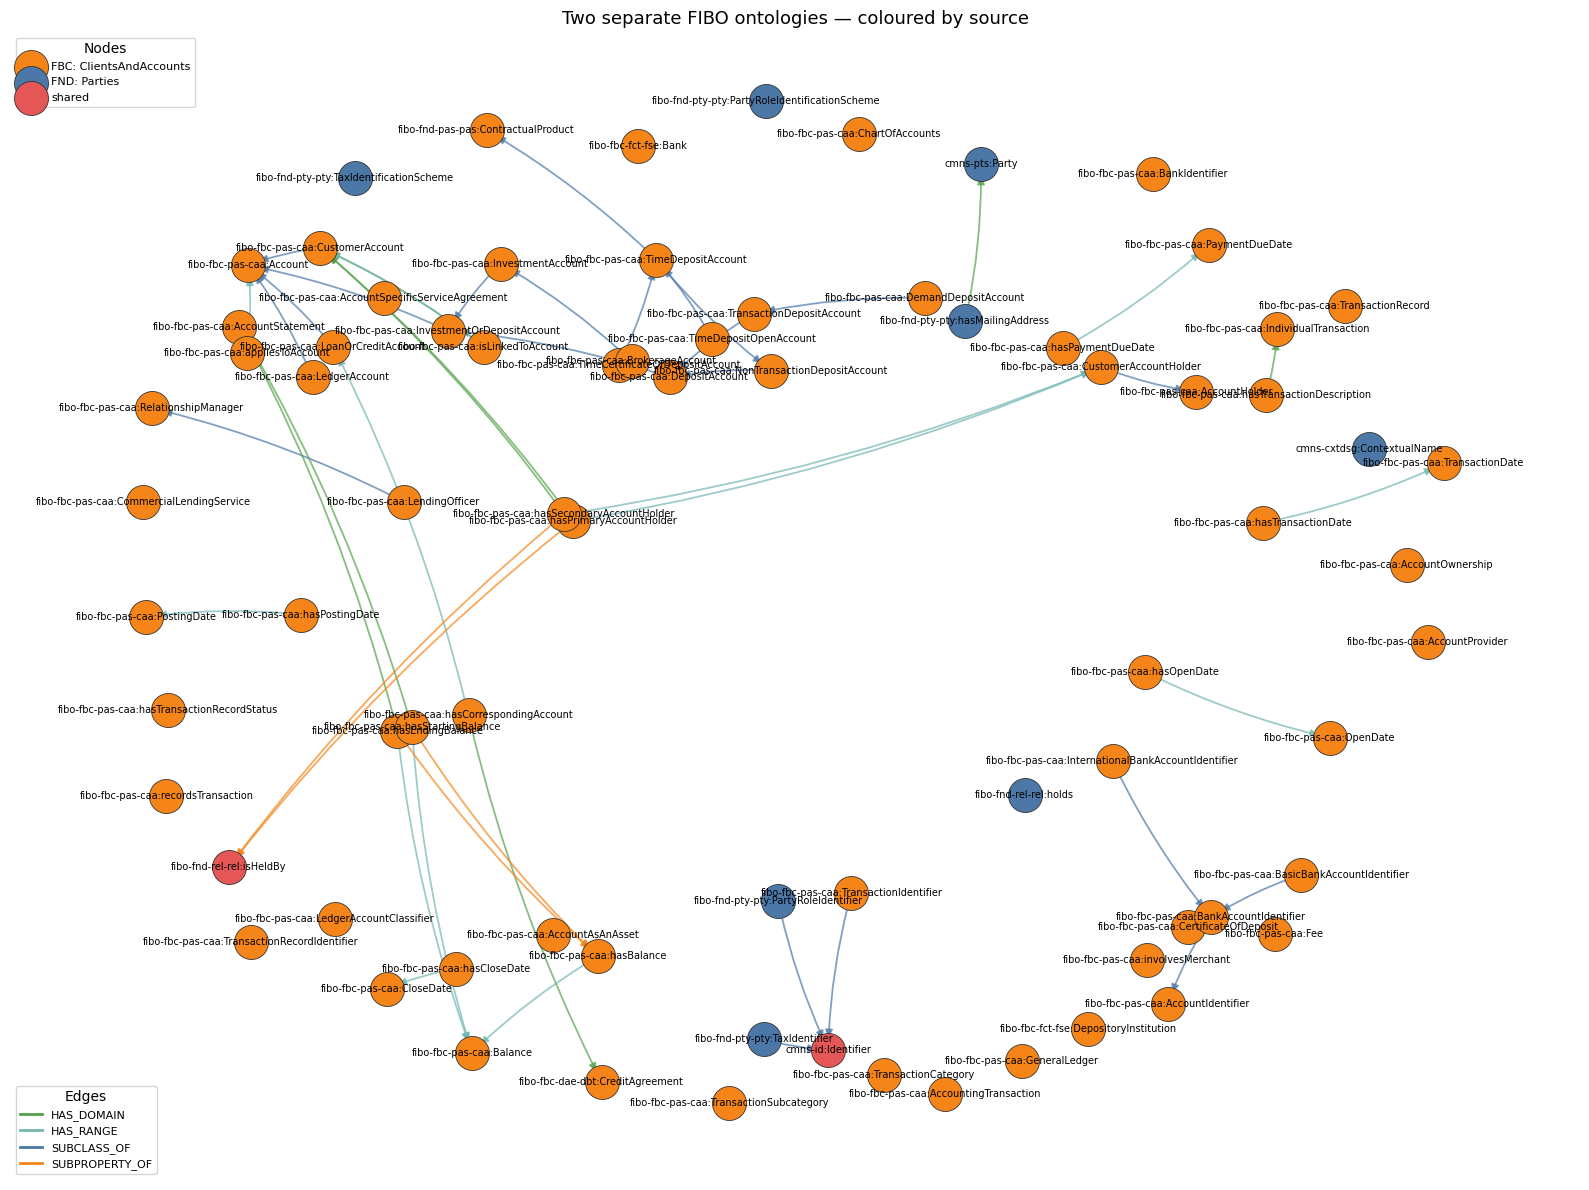

In [6]:
combined = h.compose_named({
    "FND: Parties": ir_found,
    "FBC: ClientsAndAccounts": ir_acct,
})
from collections import Counter
print("nodes by source:", dict(Counter(d.get("source") for _, d in combined.nodes(data=True))))

# keep typed schema nodes + any shared node (drop private import stubs)
keep = [n for n, d in combined.nodes(data=True)
        if d.get("source") == "shared"
        or h.primary_label(d) in {"OWLClass", "ObjectProperty", "DatatypeProperty"}]
view = combined.subgraph(keep).copy()

src_colors = {"FND: Parties": "#4C78A8",
              "FBC: ClientsAndAccounts": "#F58518",
              "shared": "#E45756"}
h.draw_meta_graph(view, "Two separate FIBO ontologies — coloured by source",
                  color_by="source", source_colors=src_colors,
                  figsize=(16, 12), node_size=600, font_size=7)

### Shared nodes — the cross-references bridging the two ontologies

In [7]:
shared = [{"qname": d.get("qname"), "label": h.primary_label(d)}
          for n, d in combined.nodes(data=True) if d.get("source") == "shared"]
pd.DataFrame(shared)

,qname,label
0,fibo-fnd-rel-rel:isHeldBy,ObjectProperty
1,cmns-id:Identifier,Resource


## Takeaways

* The pipeline loads **multiple ontologies** into independent IRs and merges them,
  attributing every schema element to its **source** ontology.
* Loaded on their own (imports not followed), *Parties* and *Clients & Accounts*
  form two largely **separate clusters** — they connect only through a few shared
  foundational references (see the table above). Following `owl:imports` with a
  local catalog would materialise the full dependency web between them.
* As in notebook 01, **nothing is written to FalkorDB** — this is load + visualise
  only. Running `FalkorDBExporter(combined)` would ingest exactly this merged graph.